In [ ]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer


In [ ]:
# Upload file
from google.colab import files
uploaded = files.upload()

Saving city_day.csv to city_day (1).csv


In [ ]:
# AQI Category
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

In [ ]:
# Load Dataset
df = pd.read_csv('/content/city_day.csv')
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
# Data Information
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
# Remove unnecessary columns
df = df.drop(['Date', 'AQI_Bucket'], axis=1)
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN
3,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN
4,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN


In [ ]:
imputer = SimpleImputer(strategy='median')

df_numeric = df.select_dtypes(include=np.number)
df_imputed_array = imputer.fit_transform(df_numeric)
df[df_numeric.columns] = df_imputed_array

In [ ]:
# Features
X = df.drop(['AQI', 'City'],axis=1)

# Target
y = df['AQI']

In [ ]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

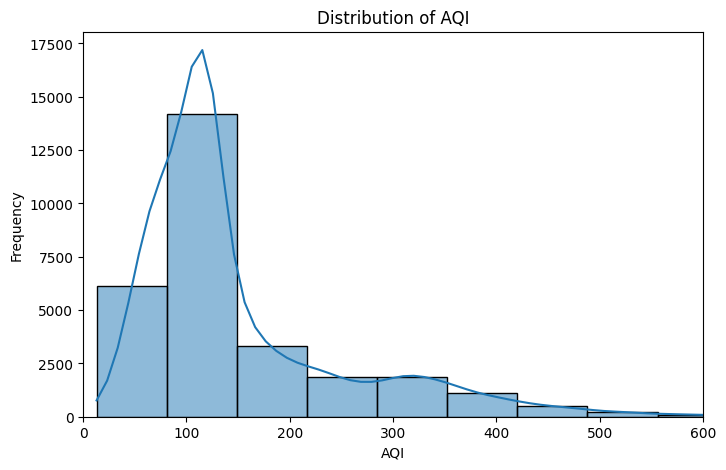

In [ ]:
# AQI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)

plt.xlim(0,600)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

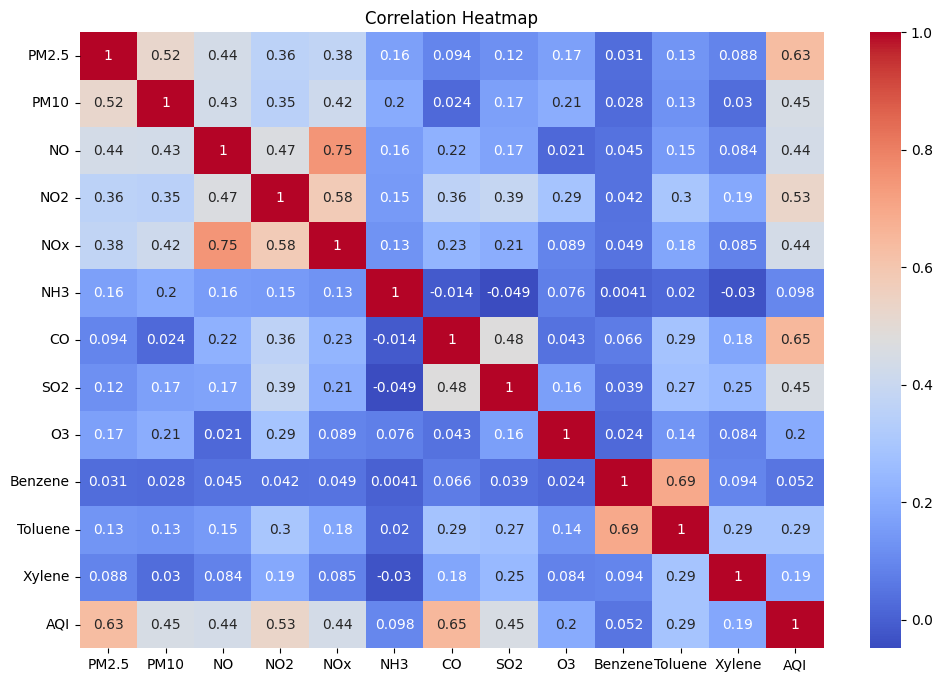

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

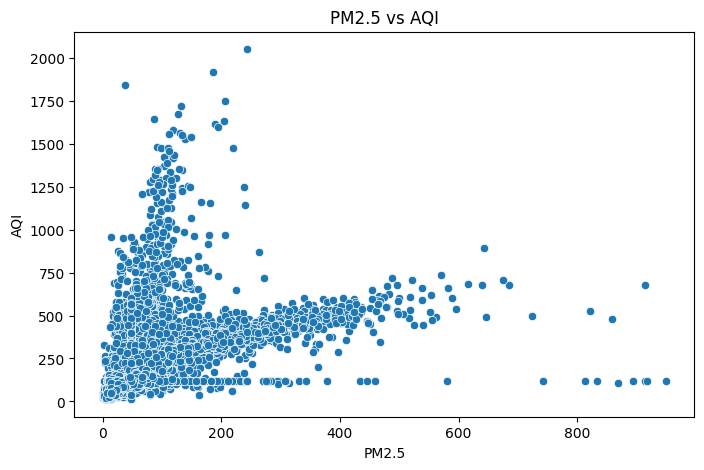

In [ ]:
# Scatterplot
plt.figure(figsize=(8,5))

sns.scatterplot(x='PM2.5', y='AQI', data=df)

plt.title("PM2.5 vs AQI")

plt.show()

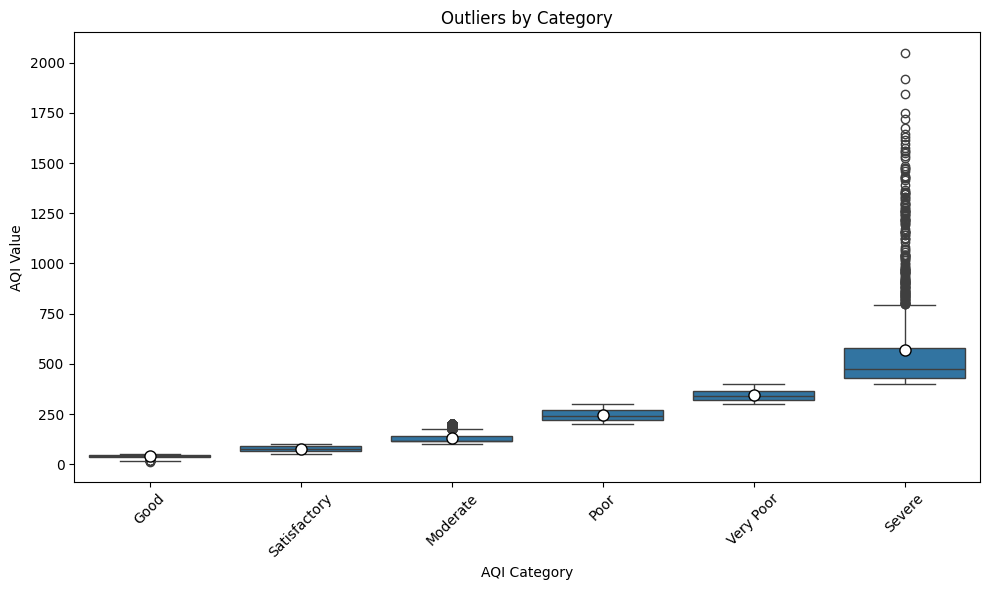

In [ ]:
# Box Plot
plt.figure(figsize=(10,6))


df['AQI_Category'] = df['AQI'].apply(get_aqi_category)

category_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

sns.boxplot(x='AQI_Category', y='AQI', data=df, order=category_order, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black","markersize":"8"})

plt.title("Outliers by Category")
plt.xlabel("AQI Category")
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


df.drop('AQI_Category', axis=1, inplace=True)

Linear Regression


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R²:", r2)

Mean Absolute Error: 29.913005380629368
Mean Squared Error: 2965.6842585878853
Root Mean Squared Error: 54.458096354792694
R²: 0.807353831320167


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
print("Best R² Score:", rf_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best R² Score: 0.870726149864649


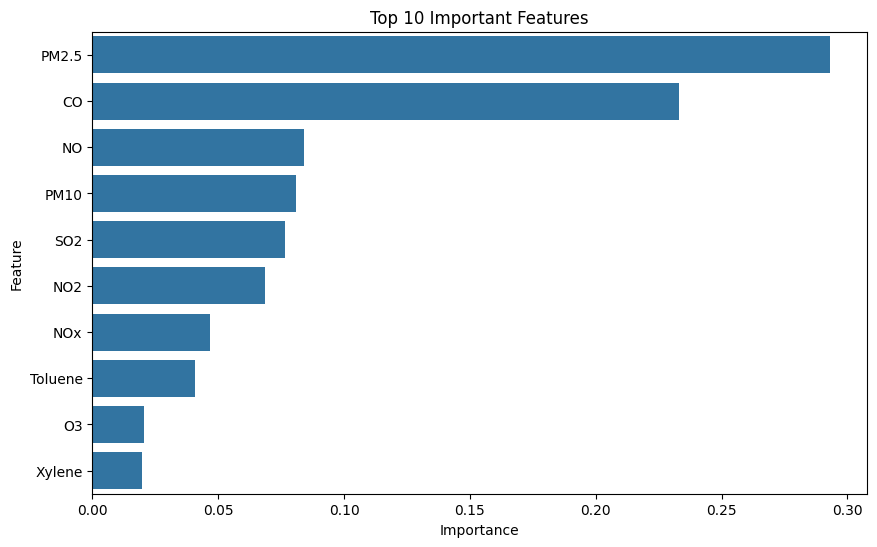

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_random.best_estimator_.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best Parameters:", xgb_random.best_params_)
print("Best R² Score:", xgb_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best R² Score: 0.8680164575904241


In [ ]:
# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf_random.best_estimator_.predict(X_test)
xgb_pred = xgb_random.best_estimator_.predict(X_test)

# Evaluation Function
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return [mae, mse, rmse, r2]

# Results
results = pd.DataFrame(
    {
        "Linear Regression": evaluate_model(y_test, lr_pred),
        "Random Forest": evaluate_model(y_test, rf_pred),
        "XGBoost": evaluate_model(y_test, xgb_pred)
    },
    index=["MAE", "MSE", "RMSE", "R² Score"]
)

print(results.T)

                         MAE          MSE       RMSE  R² Score
Linear Regression  29.913005  2965.684259  54.458096  0.807354
Random Forest      19.779589  1756.539551  41.911091  0.885898
XGBoost            20.576025  1832.722688  42.810311  0.880949


               Model  R2 Score
1      Random Forest  0.885898
2            XGBoost  0.880949
0  Linear Regression  0.807354


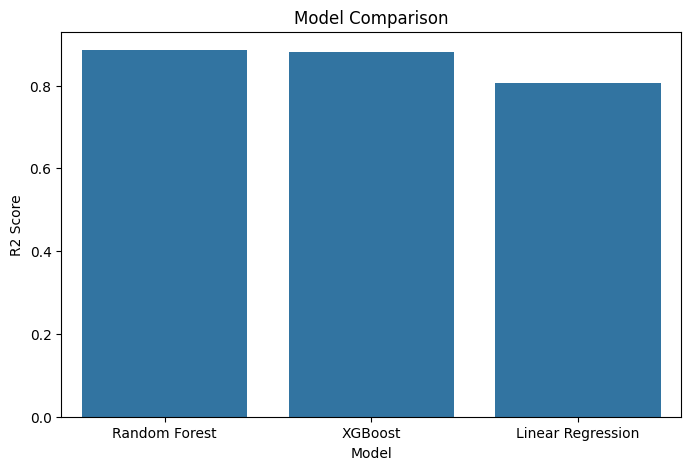

In [ ]:
# Comparison Graph
comparison = pd.DataFrame({
'Model':[
'Linear Regression',
'Random Forest',
'XGBoost'
],
'R2 Score':[
r2_score(y_test,lr_pred),
r2_score(y_test,rf_pred),
r2_score(y_test,xgb_pred)
]
})

comparison = comparison.sort_values(
    by='R2 Score',
    ascending=False
)

print(comparison)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=comparison
)

plt.title("Model Comparison")

plt.show()

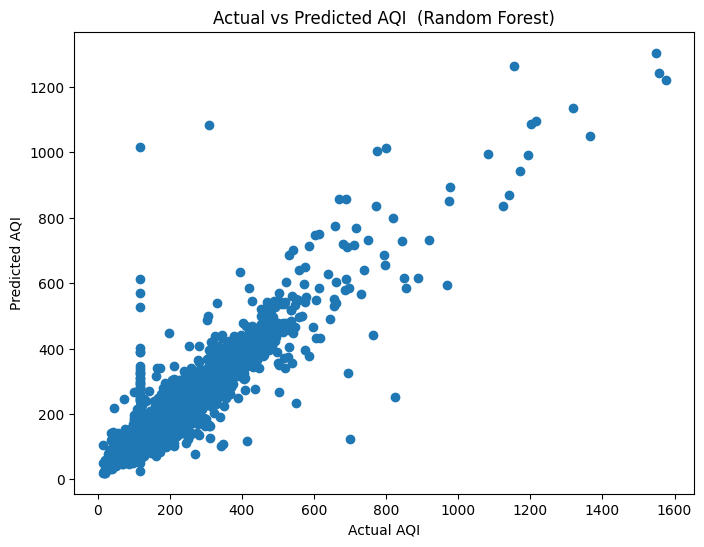

In [ ]:
# Actual vs Predicted AQI
plt.figure(figsize=(8,6))

plt.scatter(y_test,rf_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI  (Random Forest)")

plt.show()

In [ ]:
import pickle

# Pickle Storage
with open("AQI_Prediction_Model.pkl","wb") as file:
    pickle.dump(rf_random.best_estimator_,file)

In [ ]:
# Load Pickle
loaded_model = pickle.load(open('AQI_Prediction_Model.pkl','rb'))


In [ ]:
# Streamlit App
%%writefile /content/aqi_streamlit_app.py
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import streamlit as st

FEATURES = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene","Xylene"]
DEFAULTS = {"PM2.5":45,"PM10":78,"NO":12,"NO2":28,"NOx":35,"NH3":18,"CO":1.2,"SO2":15,"O3":42,"Benzene":2.5,"Toluene":8,"Xylene":3}
BANDS = [(50,"Good","#00B050"),(100,"Satisfactory","#92D050"),(200,"Moderate","#FFC000"),
         (300,"Poor","#FF6600"),(400,"Very Poor","#C00000"),(9999,"Severe","#7030A0")]

@st.cache_resource
def load_model():
    with open("/content/AQI_Prediction_Model.pkl","rb") as f:
        d = pickle.load(f)
    return (d["model"], d["feature_names"]) if isinstance(d,dict) else (d, FEATURES)

def category(aqi):
    for limit,name,color in BANDS:
        if aqi <= limit: return name, color
    return "Severe", "#7030A0"

def health_msg(aqi):
    if aqi<=50: return "Air is clean and safe for everyone."
    if aqi<=100: return "Sensitive individuals should take precautions."
    if aqi<=200: return "Limit outdoor exercise."
    if aqi<=300: return "Use masks outdoors."
    if aqi<=400: return "Stay indoors whenever possible."
    return "Severe. Health risk is high."

model, feats = load_model()
st.set_page_config(page_title="AQI Dashboard", page_icon="🌫️", layout="wide")
st.title("🌫️ AQI Dashboard")
st.markdown(""" Predict AQI levels using pollutant concentrations in the air. """)

pollutants = {}

half = len(feats)//2

col1,col2 = st.columns(2)

with col1:
  for f in feats[:half]:
    pollutants[f]= st.number_input(f,min_value=0.0,value=float(DEFAULTS.get(f,10)),step=0.1)

with col2:
  for f in feats[half:]:
    pollutants[f]= st.number_input(f,min_value=0.0,value=float(DEFAULTS.get(f,10)),step=0.1)

st.subheader("Health Profile")

c1,c2 = st.columns(2)

with c1:
  has_asthma = st.checkbox("Has Asthma")
with c2:
  is_vulnerable = st.checkbox("Child/Elderly")

if st.button("Predict AQI", type="primary"):
    row = pd.DataFrame([[pollutants[f] for f in feats]], columns=feats)
    aqi = max(float(model.predict(row)[0]), 0)
    cat, color = category(aqi)
    st.session_state["aqi"] = aqi

if "aqi" not in st.session_state:
    st.info("Enter pollutants and click Predict AQI")
    st.stop()

aqi = st.session_state["aqi"]
cat, color = category(aqi)

c1,c2 = st.columns(2)
c1.metric("Predicted AQI", f"{aqi:.1f}")
c2.metric("Category", cat)
st.subheader("Health Advisory")
st.info(health_msg(aqi))
st.progress(min(aqi/500,1.0))


if has_asthma and aqi>100: st.error("Asthma alert: keep inhaler ready")
if is_vulnerable and aqi>100: st.error("Vulnerable group: stay indoors")


Writing /content/aqi_streamlit_app.py


In [ ]:
import subprocess, time

!pip install pyngrok
!pip install streamlit
from pyngrok import ngrok, conf

# Get free token from: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3FFeGCc6ipGnrCFTrx30R4zQ6aQ_5z7wZMAiywT2A3hENqZrs")

# Kill any existing ngrok or streamlit processes to free up resources
subprocess.run(["pkill","-f","ngrok"], capture_output=True)
subprocess.run(["pkill","-f","streamlit"], capture_output=True)

subprocess.Popen([
    "streamlit","run","/content/aqi_streamlit_app.py",
    "--server.port","8501",
    "--server.headless","true",
    "--server.enableCORS","false",
    "--server.enableXsrfProtection","false",
])
time.sleep(6)
url = ngrok.connect(8501, bind_tls=True)
print("\n" + "="*50)
print("Dashboard is LIVE!")
print("Open:", url)
print("="*50)
print("Keep this Colab tab open!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.6 MB/s eta 0:00:00

Dashboard is LIVE!
Open: NgrokTunnel: "https://garage-t-shirt-sadden.ngrok-free.dev" -> "http://localhost:8501"
Keep this Colab tab open!
